# CA1 – Data Visualisation and Communication
## AI, Data Science and Software Development Employment in the USA (May 2023)

| | |
|---|---|
| **Student name** | *[Your name]* |
| **Student number** | *[Your student number]* |
| **Programme** | BSc Computing and IT – Stage 4, Semester 1 |
| **Module / Lecturer** | Data Visualisation and Communication – Taufique Ahmed |
| **Video (4 min screen capture)** | *[Paste Google Drive link – "Anyone with the link"]* |
| **GitHub repository** | *[Paste GitHub repository link – access given to tahmed1986]* |

*The CCT assessment cover page is submitted with this notebook. No data files are uploaded (see "Data source" below).*

## Introduction

**Aim.** Use visualisations to gain insights into employment in occupations involving **Artificial Intelligence (AI), Data Science and Software Development** in the USA, using the U.S. Bureau of Labor Statistics (BLS) *Occupational Employment and Wage Statistics* (OEWS) for **May 2023**, and then use earlier OEWS releases to explore how this employment changed over time (Challenge).

**Data source.** *May 2023 – All data* (`oesm23all.zip` → `all_data_M_2023.xlsx`) from https://www.bls.gov/oes/tables.htm (BLS, 2024). The file has one row per *area × industry × occupation* with employment, concentration and wage estimates.

**How each visualisation is explained.** Following the module tutorial, every chart is followed by a markdown cell covering:
1. **Objective** – what the chart is for (comparison, composition, distribution, relationship, trend).
2. **Why this chart type** – based on the data types and on clarity for the reader.
3. **What I learned** – the insight about AI / Data / Software employment.

**A note on "AI jobs".** The Standard Occupational Classification (SOC) has no occupation called "AI engineer". AI work is done mainly by *Computer and Information Research Scientists* (who research machine learning and new computing methods), *Data Scientists* and *Software Developers*. I therefore study nine SOC 2018 occupations grouped into three fields:

| Field | Occupations (SOC code) |
|---|---|
| **AI & Research** | Computer & Information Research Scientists (15-1221) |
| **Data Science** | Data Scientists (15-2051), Statisticians (15-2041), Operations Research Analysts (15-2031), Database Architects (15-1243) |
| **Software Development** | Software Developers (15-1252), Software QA Analysts & Testers (15-1253), Computer Programmers (15-1251), Web Developers (15-1254) |

The same three colours (blue = Software, orange = AI & Research, green = Data Science) are used in every chart so the reader only has to learn them once.

## 1. Setup and data preparation

In [1]:
# Import the libraries
import pandas as pd                 # data handling
import numpy as np                  # numerical python
import matplotlib.pyplot as plt     # plotting library
import matplotlib.ticker as mtick   # nicer axis number formats
import seaborn as sns               # statistical plots (heatmap)
from pathlib import Path

# A consistent look for every chart
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# One fixed colour per field, used in every chart so the reader learns it once
FIELD_COLOURS = {
    "Software Development": "#2a78d6",   # blue
    "AI & Research":        "#eb6834",   # orange
    "Data Science":         "#1baf7a",   # aqua
}
dollars = mtick.StrMethodFormatter("${x:,.0f}")
thousands = mtick.FuncFormatter(lambda x, p: f"{x/1000:,.0f}k")

In [2]:
# The data is NOT uploaded with this notebook.
# Download "May 2023 - All data" (oesm23all.zip) from https://www.bls.gov/oes/tables.htm,
# unzip it and place all_data_M_2023.xlsx inside a folder called "data" next to this notebook.
DATA_DIR = Path("data")

df = pd.read_excel(DATA_DIR / "all_data_M_2023.xlsx")   # ~400k rows, takes about a minute
print(df.shape)
df.head()

(413327, 32)


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.11,37.01,58.4,29050,35660,48060,76980,121470,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,56.19,81.29,111.36,54550,78330,116880,169090,231620,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,49.74,79.57,#,46400,66170,103460,165500,#,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN


Each row is identified by its **area** (`AREA_TYPE`: 1 = U.S., 2 = State, 4 = Metropolitan area), its **industry** (`I_GROUP`, `NAICS`) and its **occupation** (`O_GROUP`, `OCC_CODE`). To avoid double counting, every chart selects exactly one level of each.

In [3]:
# What do the "type" columns contain?
print("AREA_TYPE:", df["AREA_TYPE"].unique())      # 1 = U.S., 2 = State, 3 = Territory, 4 = Metro area, 6 = Nonmetro area
print("I_GROUP:  ", df["I_GROUP"].unique()[:6])    # industry level of the row
print("O_GROUP:  ", df["O_GROUP"].unique())        # occupation level of the row
df.dtypes.head(15)

AREA_TYPE: [1 2 3 4 6]
I_GROUP:   <StringArray>
[           'cross-industry', 'cross-industry, ownership',
                    'sector',                   '3-digit',
                   '4-digit',                   '6-digit']
Length: 6, dtype: str
O_GROUP:   <StringArray>
['total', 'major', 'minor', 'broad', 'detailed']
Length: 5, dtype: str


AREA             int64
AREA_TITLE         str
AREA_TYPE        int64
PRIM_STATE         str
NAICS              str
NAICS_TITLE        str
I_GROUP            str
OWN_CODE         int64
OCC_CODE           str
OCC_TITLE          str
O_GROUP            str
TOT_EMP         object
EMP_PRSE        object
JOBS_1000       object
LOC_QUOTIENT    object
dtype: object

**Cleaning.** BLS replaces values it cannot publish with symbols, so pandas reads the numeric columns as text. I convert them to numbers: `*`, `**` and `~` become missing values (`NaN`), and the top-coded symbol `#` (wage ≥ $239,200 a year) is replaced by $239,200 so that very high wages are kept as a lower bound instead of being lost.

In [4]:
# Numeric columns arrive as text because BLS uses symbols for missing values:
#   *  = wage estimate not available        ** = employment estimate not available
#   #  = wage is at or above $115.00/hour or $239,200/year (top-coded)
#   ~  = less than 0.5% of establishments reported
num_cols = ["TOT_EMP", "EMP_PRSE", "JOBS_1000", "LOC_QUOTIENT", "PCT_TOTAL",
            "H_MEAN", "A_MEAN", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]

TOP_CODE_ANNUAL = 239_200   # value BLS hides behind "#" in May 2023

for col in num_cols:
    s = df[col].astype(str).str.strip()
    if col.startswith("A_"):
        s = s.replace("#", str(TOP_CODE_ANNUAL))   # keep top-coded wages as the lower bound
    df[col] = pd.to_numeric(s, errors="coerce")    # "*", "**", "~" become NaN

df[num_cols].describe().T[["count", "mean", "min", "max"]]

,count,mean,min,max
TOT_EMP,401729.0,12758.953075,30.000,1.518539e+08
EMP_PRSE,401729.0,11.489593,0.000,4.990000e+01
JOBS_1000,232193.0,7.384989,0.002,1.000000e+03
LOC_QUOTIENT,232193.0,1.367247,0.020,3.498200e+02
PCT_TOTAL,162584.0,1.346167,0.000,1.000000e+02
H_MEAN,392363.0,32.475558,8.050,3.533800e+02
A_MEAN,408244.0,68109.229603,16750.000,1.805790e+06
A_PCT10,408244.0,42905.108367,15080.000,2.392000e+05
A_PCT25,408244.0,51510.702203,15080.000,2.392000e+05
A_MEDIAN,408244.0,63460.996610,15080.000,2.392000e+05


**Selecting the occupations.** The national, cross-industry, all-ownership rows (`AREA_TYPE = 1`, `I_GROUP = "cross-industry"`, `OWN_CODE = 1235`) give one figure per occupation for the whole USA. The row `00-0000 All Occupations` is kept as a benchmark.

In [5]:
# Occupations related to AI, Data Science and Software Development (SOC 2018 codes)
focus = {
    "15-1221": ("Computer & Info. Research Scientists", "AI & Research"),
    "15-2051": ("Data Scientists",                      "Data Science"),
    "15-2041": ("Statisticians",                        "Data Science"),
    "15-2031": ("Operations Research Analysts",         "Data Science"),
    "15-1243": ("Database Architects",                  "Data Science"),
    "15-1252": ("Software Developers",                  "Software Development"),
    "15-1253": ("Software QA Analysts & Testers",       "Software Development"),
    "15-1251": ("Computer Programmers",                 "Software Development"),
    "15-1254": ("Web Developers",                       "Software Development"),
}
focus_codes = list(focus)

def add_labels(frame):
    """Add a short occupation name and the field to any subset of the data."""
    frame = frame.copy()
    frame["Occupation"] = frame["OCC_CODE"].map(lambda c: focus[c][0])
    frame["Field"] = frame["OCC_CODE"].map(lambda c: focus[c][1])
    return frame

# National, cross-industry, all ownerships -> one row per occupation
national = df[(df["AREA_TYPE"] == 1) & (df["I_GROUP"] == "cross-industry") & (df["OWN_CODE"] == 1235)]
all_occ = national[national["OCC_CODE"] == "00-0000"].iloc[0]          # benchmark row: all occupations
nat = add_labels(national[national["OCC_CODE"].isin(focus_codes)])

nat[["OCC_CODE", "Occupation", "Field", "TOT_EMP", "A_MEAN", "A_MEDIAN"]].sort_values("TOT_EMP", ascending=False)

,OCC_CODE,Occupation,Field,TOT_EMP,A_MEAN,A_MEDIAN
149,15-1252,Software Developers,Software Development,1656880.0,138110.0,132270.0
150,15-1253,Software QA Analysts & Testers,Software Development,203040.0,108460.0,101800.0
165,15-2051,Data Scientists,Data Science,192710.0,119040.0,108020.0
148,15-1251,Computer Programmers,Software Development,120370.0,107750.0,99700.0
161,15-2031,Operations Research Analysts,Data Science,117880.0,95600.0,83640.0
151,15-1254,Web Developers,Software Development,85350.0,95570.0,84960.0
145,15-1243,Database Architects,Data Science,59920.0,137030.0,134700.0
138,15-1221,Computer & Info. Research Scientists,AI & Research,35210.0,157160.0,145080.0
163,15-2041,Statisticians,Data Science,29950.0,109190.0,104110.0


## 2. Visualisations – May 2023
### Visualisation 1 – Horizontal bar chart: employment by occupation

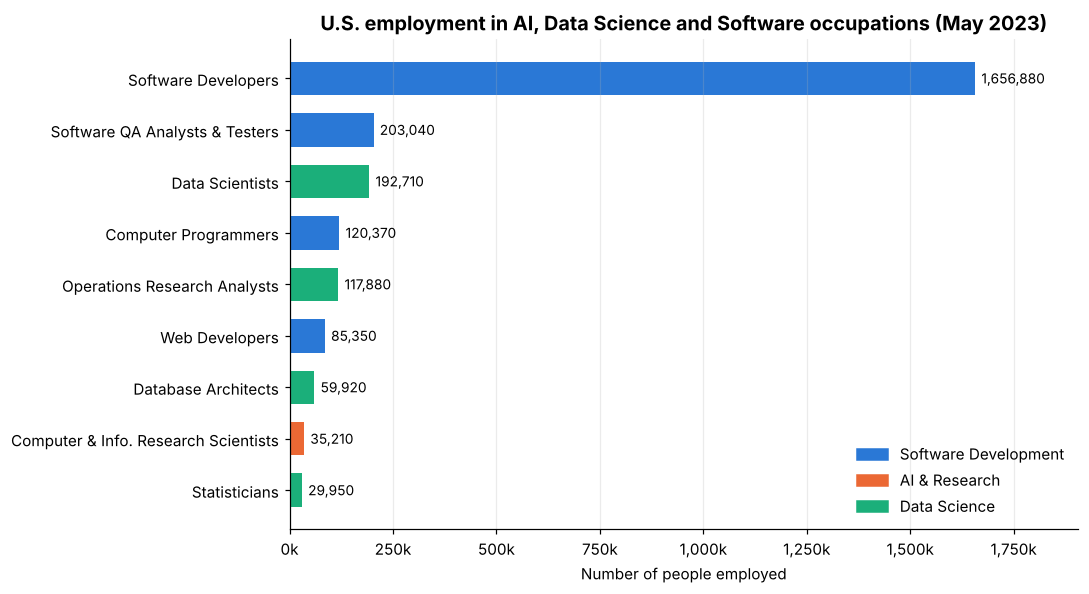

In [6]:
plot_df = nat.sort_values("TOT_EMP")
colours = plot_df["Field"].map(FIELD_COLOURS)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(plot_df["Occupation"], plot_df["TOT_EMP"], color=colours, height=0.65)

# Label each bar with its value (only 9 bars, so labels stay readable)
for bar, value in zip(bars, plot_df["TOT_EMP"]):
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height() / 2,
            f"{value:,.0f}", va="center", fontsize=9)

ax.set_title("U.S. employment in AI, Data Science and Software occupations (May 2023)")
ax.set_xlabel("Number of people employed")
ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, plot_df["TOT_EMP"].max() * 1.15)
ax.grid(axis="y", visible=False)

# Legend built from the field colours
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FIELD_COLOURS.values()]
ax.legend(handles, FIELD_COLOURS.keys(), loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

- **Objective:** *Comparison* – compare the size of each AI / Data / Software occupation and see which jobs make up this workforce.
- **Why this chart type:** The data is one **categorical** variable (occupation) and one **numerical** variable (employment). Bar length is the most accurate visual encoding for comparing quantities. Horizontal bars keep long occupation names readable without rotating them, bars are sorted so the ranking is instantly visible, and colour shows the field each job belongs to.
- **What I learned:**
  - **Software Developers dominate**: 1,656,880 people – more than all the other eight occupations together (≈ 844,000).
  - **Data Scientists (192,710)** are already the third-largest group, almost as many as Software QA Analysts & Testers (203,040).
  - The occupation closest to AI research, **Computer & Information Research Scientists, is very small (35,210)**. Building AI as a research activity employs only a few tens of thousands of people; most "AI work" in practice is done by software developers and data scientists who build and deploy AI systems.

### Visualisation 2 – Donut chart: share of the workforce by field

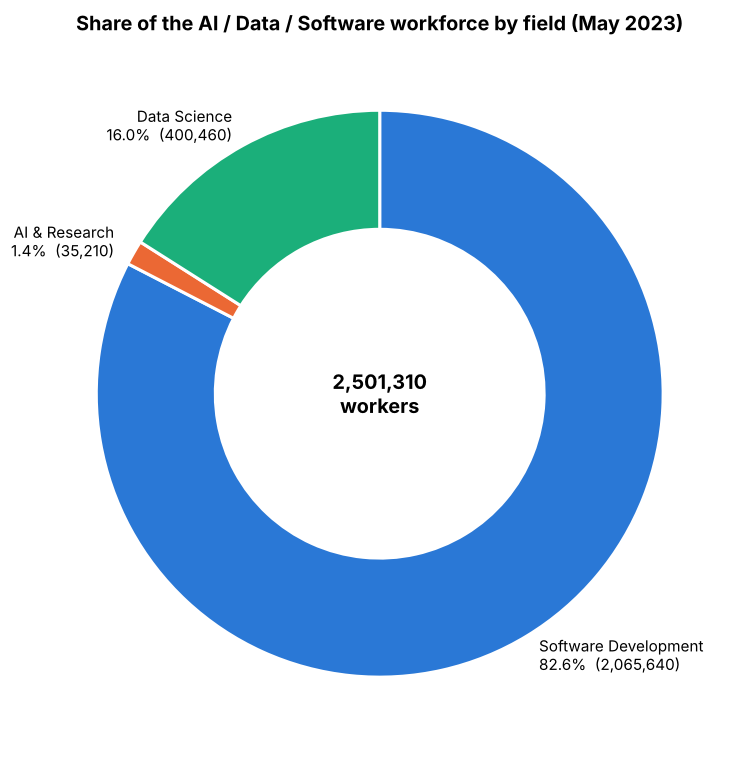

These 9 occupations represent 1.65% of all U.S. employment (151,853,870 jobs).


In [7]:
field_totals = nat.groupby("Field")["TOT_EMP"].sum().reindex(FIELD_COLOURS.keys())

pct = field_totals / field_totals.sum() * 100
labels = [f"{name}\n{p:.1f}%  ({n:,.0f})" for name, p, n in zip(field_totals.index, pct, field_totals)]

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.pie(field_totals, labels=labels, colors=FIELD_COLOURS.values(),
       startangle=90, counterclock=False, labeldistance=1.08,
       wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),   # width < 1 makes it a donut
       textprops=dict(fontsize=10))
ax.text(0, 0, f"{field_totals.sum():,.0f}\nworkers", ha="center", va="center", fontsize=13, fontweight="bold")
ax.set_title("Share of the AI / Data / Software workforce by field (May 2023)")
plt.tight_layout()
plt.show()

share_of_us = field_totals.sum() / all_occ["TOT_EMP"] * 100
print(f"These 9 occupations represent {share_of_us:.2f}% of all U.S. employment ({all_occ['TOT_EMP']:,.0f} jobs).")

- **Objective:** *Composition (part-to-whole)* – show what proportion of the AI / Data / Software workforce belongs to each field.
- **Why this chart type:** There are only **three categories that add up to one whole**, which is the situation in which a pie / donut chart works well. The donut's hole is used to display the total (2.5 million workers), and labels show both % and counts so the reader does not have to judge angles. With more categories a bar chart would be better, which is why Visualisation 1 is a bar chart.
- **What I learned:**
  - **Software Development is 82.6%** of the group (≈ 2.07 million), **Data Science 16.0%** (≈ 400,000) and **AI & Research only 1.4%** (35,210).
  - Together these nine occupations are **≈ 2.5 million jobs, about 1.65% of all 151.9 million U.S. jobs** – a small share of total employment, but, as the next chart shows, a very well-paid one.

### Visualisation 3 – Box plot: wage distribution by occupation

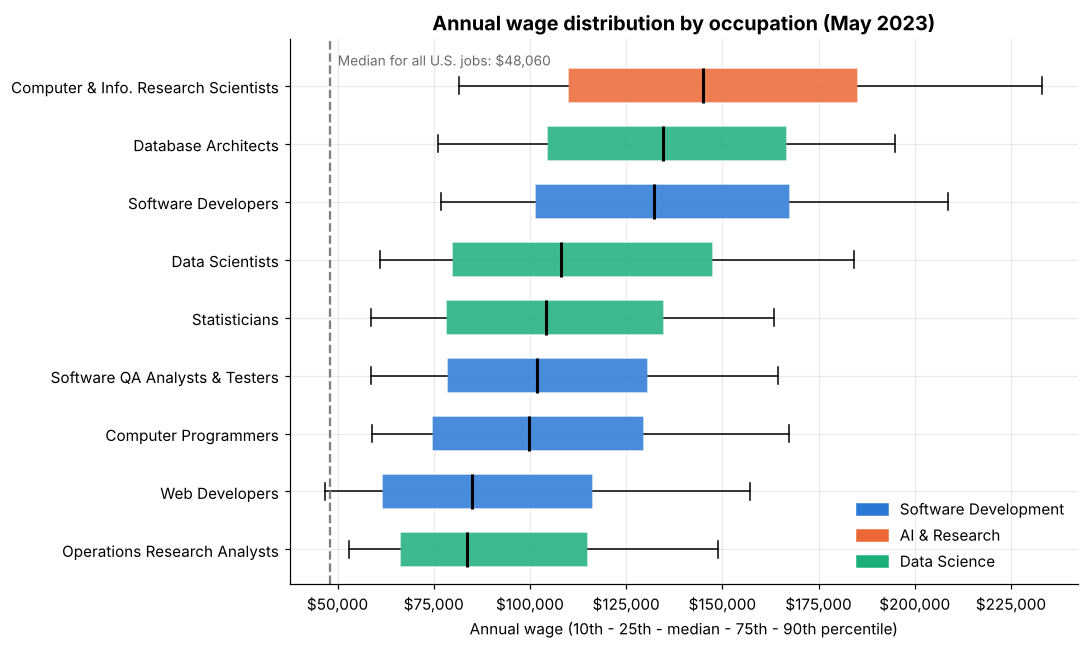

In [8]:
# BLS gives wage percentiles, not individual salaries, so we build each box from them:
# whiskers = 10th and 90th percentile, box = 25th to 75th percentile, line = median
box_df = nat.sort_values("A_MEDIAN")
stats = [dict(label=r.Occupation, whislo=r.A_PCT10, q1=r.A_PCT25, med=r.A_MEDIAN,
              q3=r.A_PCT75, whishi=r.A_PCT90, fliers=[]) for r in box_df.itertuples()]

fig, ax = plt.subplots(figsize=(10, 6))
try:
    bp = ax.bxp(stats, orientation="horizontal", patch_artist=True, widths=0.6)   # matplotlib >= 3.10
except TypeError:
    bp = ax.bxp(stats, vert=False, patch_artist=True, widths=0.6)                 # older matplotlib

for patch, field in zip(bp["boxes"], box_df["Field"]):
    patch.set_facecolor(FIELD_COLOURS[field]); patch.set_alpha(0.85); patch.set_edgecolor("white")
for median in bp["medians"]:
    median.set_color("black"); median.set_linewidth(2)

ax.axvline(all_occ["A_MEDIAN"], color="grey", linestyle="--", linewidth=1.5)
ax.text(all_occ["A_MEDIAN"] + 2000, len(stats) + 0.35,
        f"Median for all U.S. jobs: ${all_occ['A_MEDIAN']:,.0f}", color="dimgrey", fontsize=9)

ax.set_title("Annual wage distribution by occupation (May 2023)")
ax.set_xlabel("Annual wage (10th - 25th - median - 75th - 90th percentile)")
ax.xaxis.set_major_formatter(dollars)
ax.set_ylim(0.4, len(stats) + 0.8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FIELD_COLOURS.values()]
ax.legend(handles, FIELD_COLOURS.keys(), loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

- **Objective:** *Distribution and comparison* – compare not only the typical (median) pay of each occupation but also how spread out pay is, and compare it with the U.S. median for all jobs.
- **Why this chart type:** Wage is a **continuous numerical** variable and an average alone hides inequality. A box plot shows the median, the middle 50% (box) and the range (whiskers) in one compact shape, so nine distributions can be compared side by side. Because BLS publishes percentiles rather than individual salaries, each box is built from the 10th, 25th, 50th, 75th and 90th percentiles (whiskers = 10th and 90th percentile), using `Axes.bxp`.
- **What I learned:**
  - **Every occupation's median is far above the all-jobs median of $48,060** – even the lowest (Operations Research Analysts, $83,640) earns about 1.7×, and the 10th percentile of most of these jobs is above the U.S. median.
  - **The AI-research occupation pays the most:** Computer & Information Research Scientists have the highest median ($145,080) and the widest box; their 90th percentile ($233,110) is close to the BLS top-code. Scarce AI research skills command a clear premium.
  - Software Developers ($132,270) and Database Architects ($134,700) come next, while **Data Scientists ($108,020)** earn less than software developers at the median but have a long upper whisker (90th percentile $184,090) – pay depends strongly on seniority and employer.

### Visualisation 4 – Heatmap: concentration of jobs by state (location quotient)

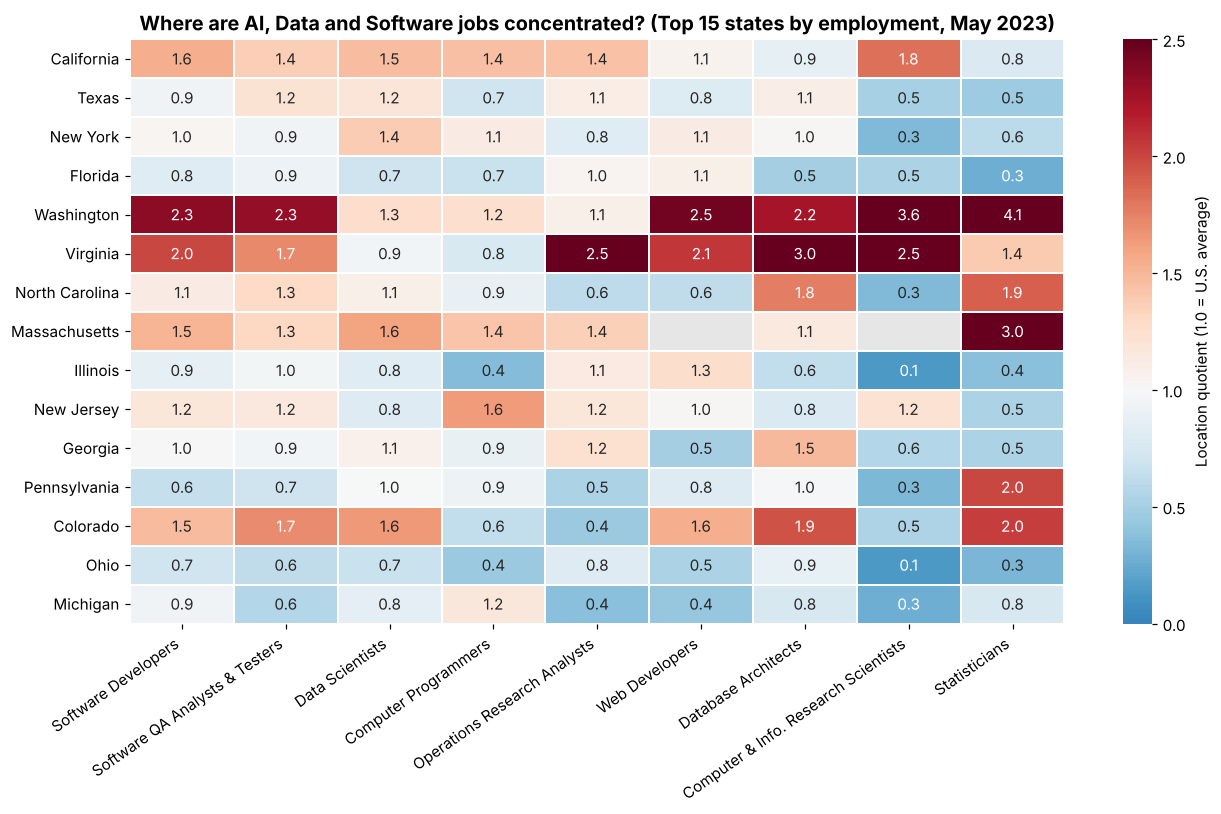

In [9]:
# State-level rows (AREA_TYPE 2). Location quotient (LQ) = how concentrated a job is in a state
# compared with the U.S. average: LQ 1.0 = average, 2.0 = twice as concentrated.
states = add_labels(df[(df["AREA_TYPE"] == 2) & (df["OCC_CODE"].isin(focus_codes))])

# Keep the 15 states with the largest combined AI / Data / Software workforce
top_states = states.groupby("AREA_TITLE")["TOT_EMP"].sum().nlargest(15).index
lq = (states[states["AREA_TITLE"].isin(top_states)]
      .pivot_table(index="AREA_TITLE", columns="Occupation", values="LOC_QUOTIENT")
      .reindex(top_states)                                    # biggest state first
      [nat.sort_values("TOT_EMP", ascending=False)["Occupation"]])   # biggest occupation first

fig, ax = plt.subplots(figsize=(12, 7.5))
ax.set_facecolor("#e6e6e6")   # grey = estimate not published by BLS
sns.heatmap(lq, annot=True, fmt=".1f", cmap="RdBu_r", center=1, vmin=0, vmax=2.5,
            linewidths=1, linecolor="white", cbar_kws=dict(label="Location quotient (1.0 = U.S. average)"), ax=ax)
ax.set_title("Where are AI, Data and Software jobs concentrated? (Top 15 states by employment, May 2023)")
ax.set_xlabel(""); ax.set_ylabel(""); ax.grid(False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

- **Objective:** *Comparison across two categorical dimensions* – find which states specialise in which AI / Data / Software occupations.
- **Why this chart type:** The data is a matrix (15 states × 9 occupations = 135 values). A table of numbers would be hard to scan, but a heatmap turns it into a pattern the eye picks up immediately. I used the **location quotient** (LQ), not raw employment, because big states would otherwise always look "biggest". LQ has a natural midpoint (1.0 = U.S. average), so a **diverging** colour scale (blue = below average, white = average, red = above) is the correct choice. Grey cells are estimates BLS did not publish.
- **What I learned:**
  - **California has the most jobs** (≈ 438,000 in these occupations), and the five largest states hold about 43% of the total – but size is not the same as specialisation.
  - **Washington State is the most specialised**: LQ 2.3 for Software Developers, 3.6 for Research Scientists and 4.1 for Statisticians (the Seattle tech cluster).
  - **Virginia** stands out for Database Architects (3.0), Operations Research Analysts (2.5) and Research Scientists (2.5) – consistent with government and defence contracting around Washington D.C.
  - **Data Scientists are more evenly spread** (max LQ ≈ 1.6, in Colorado, Massachusetts and California), suggesting data science is needed in many industries and places, whereas AI research is concentrated in a few hubs. States such as Ohio and Illinois have very low LQs (≈ 0.1) for AI research.

### Visualisation 5 – Bubble scatter plot: concentration vs pay in metro areas

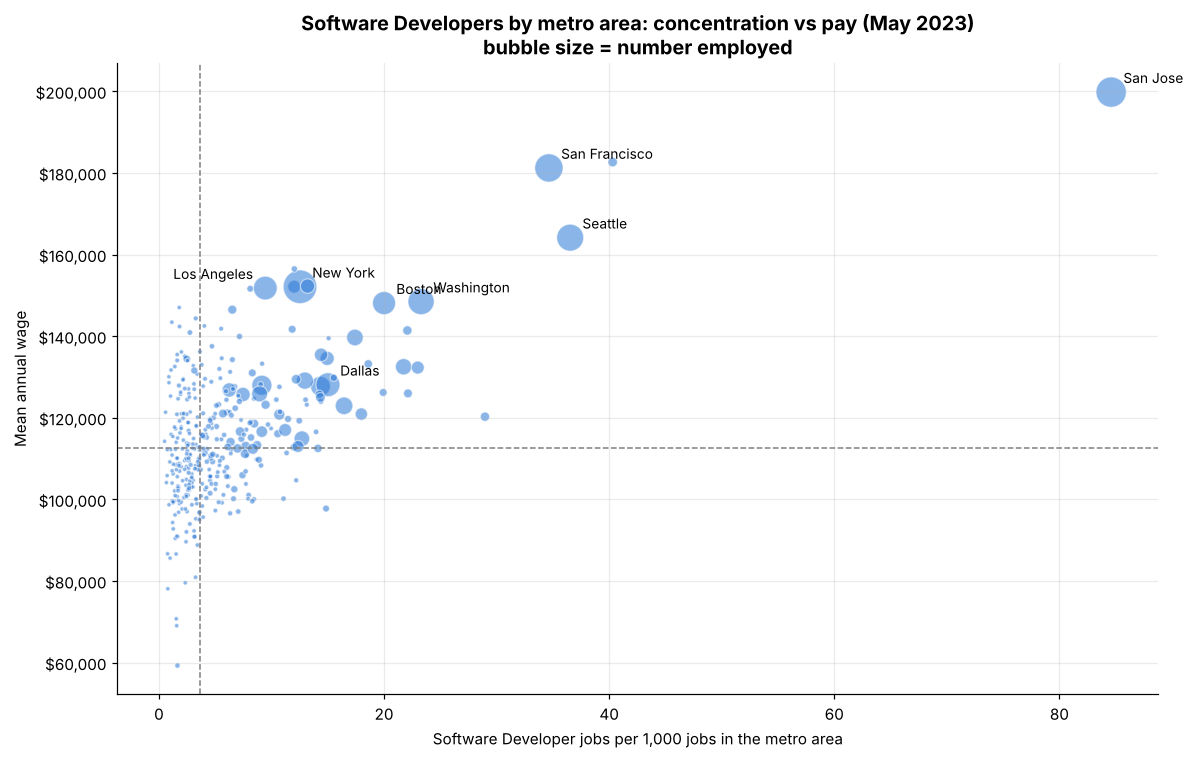

Correlation between concentration and mean wage: 0.55


In [10]:
# Metropolitan areas (AREA_TYPE 4) for Software Developers, the largest occupation in the group
metro = df[(df["AREA_TYPE"] == 4) & (df["OCC_CODE"] == "15-1252")].dropna(subset=["TOT_EMP", "A_MEAN", "JOBS_1000"])

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(metro["JOBS_1000"], metro["A_MEAN"], s=metro["TOT_EMP"] / 250 + 8,
           color=FIELD_COLOURS["Software Development"], alpha=0.55, edgecolor="white", linewidth=0.8)

# Label only the 8 largest metros (selective labels keep the chart readable)
for _, r in metro.nlargest(8, "TOT_EMP").iterrows():
    name = r["AREA_TITLE"].split(",")[0].split("-")[0]
    left = name in ("Los Angeles",)                       # avoid overlapping with New York
    ax.annotate(name, (r["JOBS_1000"], r["A_MEAN"]), xytext=(-8 if left else 8, 6),
                textcoords="offset points", fontsize=9, ha="right" if left else "left")

ax.axhline(metro["A_MEAN"].median(), color="grey", linestyle="--", linewidth=1)
ax.axvline(metro["JOBS_1000"].median(), color="grey", linestyle="--", linewidth=1)
ax.set_title("Software Developers by metro area: concentration vs pay (May 2023)\nbubble size = number employed")
ax.set_xlabel("Software Developer jobs per 1,000 jobs in the metro area")
ax.set_ylabel("Mean annual wage")
ax.yaxis.set_major_formatter(dollars)
plt.tight_layout()
plt.show()

print("Correlation between concentration and mean wage:", round(metro["JOBS_1000"].corr(metro["A_MEAN"]), 2))

- **Objective:** *Relationship* – investigate whether metro areas with a higher concentration of Software Developers also pay them more.
- **Why this chart type:** Two **continuous numerical** variables (jobs per 1,000 and mean wage) for ~380 metro areas – a scatter plot is the standard way to show a relationship between them. Bubble size adds a third variable (number employed) without needing another chart. Only the 8 largest metros are labelled to avoid clutter, and dashed median lines split the chart into four quadrants.
- **What I learned:**
  - There is a **moderate positive relationship (r ≈ 0.55)**: where software jobs are more concentrated, pay is higher.
  - **San Jose (Silicon Valley) is an extreme outlier**: about 85 software-developer jobs per 1,000 jobs and a mean wage of about $199,800 – roughly 1.8× the median metro (≈ $112,700). San Francisco and Seattle follow.
  - Most metros cluster in the bottom-left: below 10 jobs per 1,000 and $90k–$130k pay. The 10 largest metros account for almost half (≈ 49%) of all software developer jobs – **tech employment is highly geographically concentrated**.

### Visualisation 6 – 100% stacked bar chart: which industries employ these workers

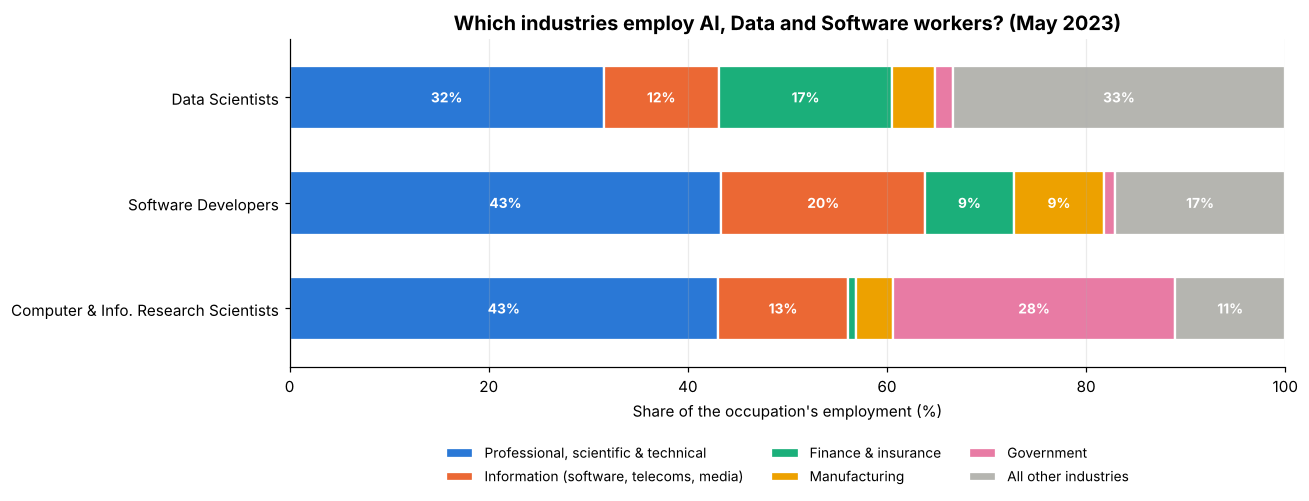

In [11]:
# Industry (NAICS sector) rows at national level for three key occupations
key_occ = {"15-1252": "Software Developers", "15-2051": "Data Scientists", "15-1221": "Computer & Info. Research Scientists"}
sector = df[(df["AREA_TYPE"] == 1) & (df["I_GROUP"] == "sector") & (df["OCC_CODE"].isin(key_occ))]

ind = sector.pivot_table(index="OCC_CODE", columns="NAICS", values="TOT_EMP", aggfunc="sum").fillna(0)
ind.index = ind.index.map(key_occ)

# The five biggest employing sectors (NAICS codes) get their own colour; the rest are grouped
short = {"54": "Professional, scientific & technical",
         "51": "Information (software, telecoms, media)",
         "52": "Finance & insurance",
         "31-33": "Manufacturing",
         "99": "Government"}
ind_share = ind[list(short)].rename(columns=short)
ind_share["All other industries"] = ind.drop(columns=list(short)).sum(axis=1)
ind_share = ind_share.div(ind_share.sum(axis=1), axis=0) * 100      # convert to % of each occupation

colours = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#b5b5b0"]   # grey = "other"
ax = ind_share.plot(kind="barh", stacked=True, figsize=(12, 4.8), color=colours, width=0.6, edgecolor="white", linewidth=1.5)

for container in ax.containers:                       # label segments that are wide enough
    labels = [f"{w:.0f}%" if w >= 6 else "" for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Which industries employ AI, Data and Software workers? (May 2023)")
ax.set_xlabel("Share of the occupation's employment (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

- **Objective:** *Composition and comparison* – compare the industry mix of three key AI-related occupations.
- **Why this chart type:** For each occupation we want the **parts of a whole (100%)** and we want to compare **three wholes**. Three pie charts would be hard to compare; a 100% stacked bar puts them on the same scale so segment widths can be compared directly. Only the five largest sectors get their own colour and the rest are grouped as "All other industries" (grey) to keep the chart readable.
- **What I learned:**
  - **Professional, scientific & technical services** (consultancies, computer-systems design, R&D firms) is the biggest employer of all three occupations (32–43%).
  - **Computer & Information Research Scientists depend heavily on government (28%)** – AI research is still strongly linked to public/defence research – and the Information sector (13%).
  - **Data Scientists are the most spread across industries**: finance & insurance alone employs 17% and one-third work in "all other industries" (e.g. health care, management of companies, retail). Data science is a horizontal skill that every sector is adopting, while Software Developers are concentrated in tech-producing sectors (Professional services + Information = 63%).

### Visualisation 7 – Overlapping histogram: pay across metro areas

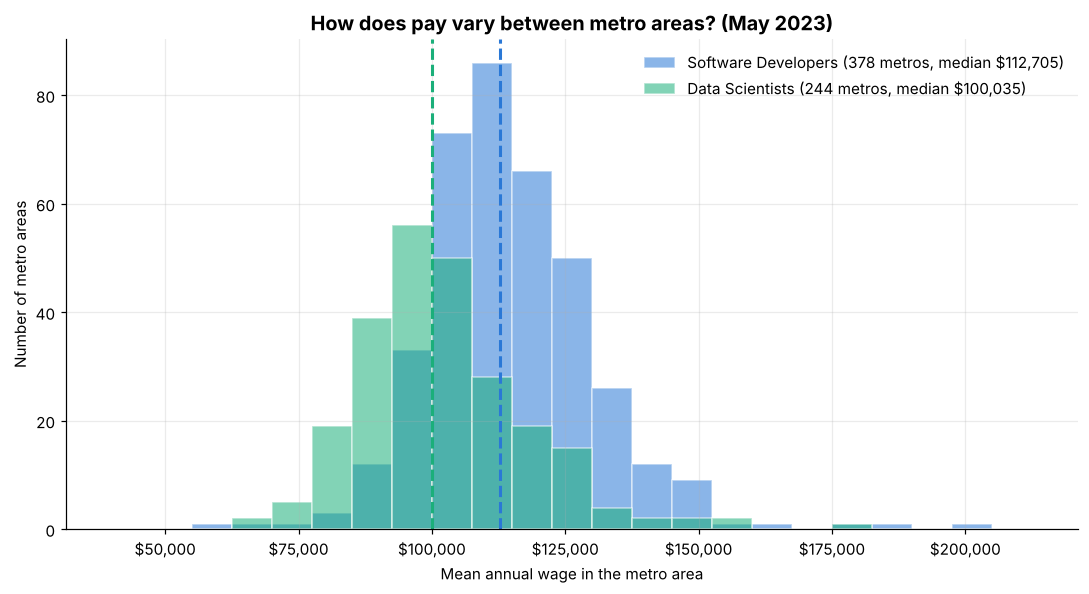

In [12]:
# Distribution of mean annual wage across metro areas: Data Scientists vs Software Developers
metro_wages = add_labels(df[(df["AREA_TYPE"] == 4) & (df["OCC_CODE"].isin(["15-2051", "15-1252"]))])

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(40_000, 220_000, 7_500)
for occ, field in [("Software Developers", "Software Development"), ("Data Scientists", "Data Science")]:
    w = metro_wages.loc[metro_wages["Occupation"] == occ, "A_MEAN"].dropna()
    ax.hist(w, bins=bins, alpha=0.55, color=FIELD_COLOURS[field], edgecolor="white",
            label=f"{occ} ({len(w)} metros, median ${w.median():,.0f})")
    ax.axvline(w.median(), color=FIELD_COLOURS[field], linestyle="--", linewidth=2)

ax.set_title("How does pay vary between metro areas? (May 2023)")
ax.set_xlabel("Mean annual wage in the metro area")
ax.set_ylabel("Number of metro areas")
ax.xaxis.set_major_formatter(dollars)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- **Objective:** *Distribution and comparison* – see how much pay for the same job varies between metro areas, and compare Data Scientists with Software Developers.
- **Why this chart type:** Mean wage per metro is a **continuous** variable with hundreds of values; a histogram shows the shape of its distribution (centre, spread, skew, outliers). Overlaying the two occupations with transparency, the same bins and dashed median lines makes the comparison direct.
- **What I learned:**
  - Both distributions are **right-skewed**: most metros pay $90k–$130k, but a few tech hubs pay far more (up to ≈ $200k).
  - Across metros, **Software Developers earn more than Data Scientists** (median metro ≈ $112,700 vs ≈ $100,000), which agrees with the national box plot.
  - Data Scientists appear in fewer metros with published estimates (244 vs 378), another sign that this newer occupation is still smaller and more concentrated than software development.

## 3. Challenge – AI employment trends over time

**Additional datasets.** National OEWS files for earlier years from https://www.bls.gov/oes/tables.htm (BLS, 2024): `oesm15nat.zip` … `oesm22nat.zip` (May 2015 – May 2022), combined with the May 2023 data above.

**Comparability problem.** BLS moved from SOC 2010 to SOC 2018. May 2019 and May 2020 use temporary *hybrid* codes and the full SOC 2018 starts in May 2021 (BLS, 2021). For example, *Data Scientists* only got their own code (15-2051) in 2021; in 2019–2020 they were in 15-2098 "Data Scientists and Mathematical Science Occupations, All Other"; before 2019 they did not have a code at all. To compare like with like I:
1. map every old/hybrid/new code to one **harmonised group** (e.g. 15-1132 + 15-1133 → 15-1256 → 15-1252 + 15-1253 for software developers & testers), and
2. compare those groups only **from 2019 onwards**, while occupations whose definition never changed (Programmers, Statisticians, OR Analysts, Research Scientists) are also shown over the longer 2015–2023 period.

`*` *Data Scientists* = 15-2051 + 15-2099 (2021+) so that it matches the hybrid 15-2098 used in 2019–2020.

*Caution:* OEWS estimates are built from three years of survey panels, so BLS advises care when comparing single years; the charts are used to show the **direction and size** of change, not exact year-to-year differences.

In [ ]:
# Download the "National" file for each extra year from https://www.bls.gov/oes/tables.htm
# (e.g. oesm22nat.zip, oesm21nat.zip ... oesm15nat.zip), unzip them and put the
# national_M20XX_dl.xlsx files inside the same "data" folder. The code finds them automatically.
import re

def load_national(path):
    """Read one BLS national file and standardise the column names across years."""
    year = int(re.search(r"(20\d\d)", path.name).group(1))
    d = pd.read_excel(path)
    d.columns = d.columns.str.upper().str.strip()          # 2019+ files use lower case names
    d = d.rename(columns={"OCC_GROUP": "O_GROUP"})         # older files call it OCC_GROUP
    if "I_GROUP" in d.columns:                              # keep the all-industry rows only
        d = d[d["I_GROUP"].astype(str).str.contains("cross-industry") & ~d["I_GROUP"].astype(str).str.contains("ownership")]
    d = d[d["O_GROUP"].astype(str).str.lower() == "detailed"].copy()
    for col in ["TOT_EMP", "A_MEAN", "A_MEDIAN"]:
        d[col] = pd.to_numeric(d[col].astype(str).str.replace(",", "").str.strip(), errors="coerce")
    d["YEAR"] = year
    return d[["YEAR", "OCC_CODE", "OCC_TITLE", "TOT_EMP", "A_MEAN", "A_MEDIAN"]]

files = sorted(DATA_DIR.rglob("national_M20*_dl.xls*"))
print("Files found:", [f.name for f in files])
history = pd.concat([load_national(f) for f in files], ignore_index=True)

# Add May 2023 from the main dataset so the series ends at the same year
nat_2023 = national[national["O_GROUP"] == "detailed"][["OCC_CODE", "OCC_TITLE", "TOT_EMP", "A_MEAN", "A_MEDIAN"]].assign(YEAR=2023)
history = pd.concat([history[history["YEAR"] != 2023], nat_2023], ignore_index=True)
history.groupby("YEAR").size()

In [ ]:
# BLS changed its occupation codes (SOC 2010 -> SOC 2018) between 2018 and 2021.
# 2019 and 2020 use temporary "hybrid" codes. To compare like with like, each group
# below adds up every code that was used for that job in any year (codes never overlap in the same year).
groups = {
    "Software Developers & QA Testers": (["15-1132", "15-1133", "15-1256", "15-1252", "15-1253"], "Software Development"),
    "Computer Programmers":             (["15-1131", "15-1251"],                                 "Software Development"),
    "Web Developers & Designers":       (["15-1134", "15-1257", "15-1254", "15-1255"],           "Software Development"),
    "Data Scientists*":                 (["15-2098", "15-2051", "15-2099"],                      "Data Science"),
    "Statisticians":                    (["15-2041"],                                            "Data Science"),
    "Operations Research Analysts":     (["15-2031"],                                            "Data Science"),
    "Computer & Info. Research Scientists": (["15-1111", "15-1221"],                             "AI & Research"),
}
code_to_group = {code: g for g, (codes, _) in groups.items() for code in codes}
group_field = {g: field for g, (_, field) in groups.items()}

h = history[history["OCC_CODE"].isin(code_to_group)].copy()
h["Group"] = h["OCC_CODE"].map(code_to_group)
h["Field"] = h["Group"].map(group_field)
h["WAGE_BILL"] = h["TOT_EMP"] * h["A_MEAN"]              # used to build an employment-weighted mean wage

trend = h.groupby(["Group", "YEAR"]).agg(TOT_EMP=("TOT_EMP", "sum"), WAGE_BILL=("WAGE_BILL", "sum")).reset_index()
trend["A_MEAN"] = trend["WAGE_BILL"] / trend["TOT_EMP"]
trend["Field"] = trend["Group"].map(group_field)

# Data Scientists, QA testers and digital designers had no code of their own before 2019,
# so the group totals are only comparable from 2019 onwards (hybrid SOC codes).
COMPARABLE_FROM = 2019
STABLE = ["Computer Programmers", "Statisticians", "Operations Research Analysts",
          "Computer & Info. Research Scientists"]        # same definition in every year -> long run is fine

trend_c = trend[trend["YEAR"] >= COMPARABLE_FROM]
emp_wide = trend_c.pivot(index="YEAR", columns="Group", values="TOT_EMP")
trend.pivot(index="YEAR", columns="Group", values="TOT_EMP").style.format("{:,.0f}", na_rep="-")

### Challenge visualisation A – Stacked area chart: total employment by field

In [ ]:
field_year = trend_c.groupby(["YEAR", "Field"])["TOT_EMP"].sum().unstack()[list(FIELD_COLOURS)]

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(field_year.index, field_year.T.values, labels=field_year.columns,
             colors=FIELD_COLOURS.values(), alpha=0.9, edgecolor="white", linewidth=1.5)
ax.plot(field_year.index, field_year.sum(axis=1), color="black", marker="o", linewidth=1.5, label="Total")
for year, total in field_year.sum(axis=1).items():
    ax.annotate(f"{total/1e6:.2f}M", (year, total), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)

ax.set_title(f"AI, Data and Software employment in the U.S., {field_year.index[0]}-{field_year.index[-1]} (May of each year)")
ax.set_xlabel("Year"); ax.set_ylabel("Number employed")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M"))
ax.set_xticks(field_year.index)
ax.set_ylim(0, field_year.sum(axis=1).max() * 1.12)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

- **Objective:** *Trend and composition over time* – show how the whole AI / Data / Software workforce grew and how its make-up changed.
- **Why this chart type:** Time (year) is an **ordered** variable, so a line-based chart is natural. A stacked area adds the **part-to-whole** information: the top edge (black line) is the total and each band is a field. It suits data where the parts add up to a meaningful total.
- **What I learned:**
  - The group grew steadily every year from 2019 to 2023; the labels above the line give the total each year.
  - Software development is always the largest band, but the **Data Science band widens the most**, so its share of the workforce increased.
  - The AI & Research band remains thin throughout – the growth of "AI" employment is visible mainly through data scientists and developers rather than research scientists.

### Challenge visualisation B – Indexed line chart: growth rate by occupation

In [ ]:
# Index every group to its first year = 100, so small and large jobs share one axis
indexed = emp_wide.div(emp_wide.iloc[0]) * 100
line_colours = {"Software Developers & QA Testers": "#2a78d6", "Computer Programmers": "#6da7ec",
                "Web Developers & Designers": "#184f95", "Data Scientists*": "#1baf7a",
                "Statisticians": "#0b6e4a", "Operations Research Analysts": "#5cc79f",
                "Computer & Info. Research Scientists": "#eb6834"}
styles = {"Software Development": "-", "Data Science": "--", "AI & Research": "-."}

fig, ax = plt.subplots(figsize=(11, 6.5))
for group in indexed.columns:
    ax.plot(indexed.index, indexed[group], marker="o", linewidth=2,
            color=line_colours[group], linestyle=styles[group_field[group]], label=group)
    ax.annotate(f"{indexed[group].iloc[-1]:.0f}", (indexed.index[-1], indexed[group].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)

ax.axhline(100, color="grey", linewidth=1)
ax.set_title(f"Employment growth by occupation ({indexed.index[0]} = 100)")
ax.set_xlabel("Year"); ax.set_ylabel(f"Employment index ({indexed.index[0]} = 100)")
ax.set_xticks(indexed.index)
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

- **Objective:** *Trend comparison* – compare **growth rates** of occupations of very different sizes.
- **Why this chart type:** Software Developers (≈ 1.9 million) and Statisticians (≈ 30,000) cannot share a normal axis – the small jobs would look flat. **Indexing each series to 2019 = 100** puts all of them on one comparable scale (percentage growth) and avoids a misleading dual-axis chart. Colour shows the field and line style (solid / dashed / dash-dot) gives a second cue for colour-blind readers.
- **What I learned:**
  - **Data Scientists grew fastest of all occupations** – their index rises far above every other line, showing how rapidly organisations have been hiring data and AI talent.
  - Software Developers & QA Testers and Research Scientists also grew clearly above 100, while **Computer Programmers is the only line below 100** – routine coding is shrinking as work moves to broader software-developer roles and automation.

### Challenge visualisation C – Diverging bar chart: % change in employment

In [ ]:
first, last = emp_wide.index[0], emp_wide.index[-1]
change = ((emp_wide.loc[last] / emp_wide.loc[first] - 1) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colours = [FIELD_COLOURS[group_field[g]] for g in change.index]
bars = ax.barh(change.index, change.values, color=colours, height=0.6)
for bar, value, g in zip(bars, change.values, change.index):
    extra = f"  ({emp_wide.loc[first, g]:,.0f} -> {emp_wide.loc[last, g]:,.0f})"
    ax.text(value + (2 if value >= 0 else -2), bar.get_y() + bar.get_height() / 2,
            f"{value:+.0f}%{extra}", va="center", ha="left" if value >= 0 else "right", fontsize=9)

ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Change in employment, {first} to {last}")
ax.set_xlabel("% change in number employed")
ax.set_xlim(min(change.min() * 1.9, -10), change.max() * 1.9)
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FIELD_COLOURS.values()]
ax.legend(handles, FIELD_COLOURS.keys(), loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

- **Objective:** *Comparison of change* – summarise the trend into one number per occupation (growth or decline between the first and last comparable year).
- **Why this chart type:** The value is a **positive or negative percentage**, so a horizontal bar chart with a zero line shows both direction and size; sorting ranks winners and losers. Labels give the actual start and end employment so the percentages are not misleading for small occupations.
- **What I learned:**
  - The ranking confirms the line chart: **Data Scientists have the largest % increase**, followed by the other Data Science and AI occupations, while **Computer Programmers declined**.
  - In absolute numbers, however, **Software Developers & QA Testers added by far the most jobs** – a reminder that percentage growth and absolute growth tell different stories.

### Challenge visualisation D – Line chart: wage trends

In [ ]:
wage_wide = trend_c.pivot(index="YEAR", columns="Group", values="A_MEAN")
show = ["Computer & Info. Research Scientists", "Software Developers & QA Testers", "Data Scientists*", "Computer Programmers"]

fig, ax = plt.subplots(figsize=(11, 6))
for group in show:
    ax.plot(wage_wide.index, wage_wide[group], marker="o", linewidth=2,
            color=line_colours[group], linestyle=styles[group_field[group]], label=group)
    ax.annotate(f"${wage_wide[group].iloc[-1]:,.0f}", (wage_wide.index[-1], wage_wide[group].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9)

ax.set_title(f"Mean annual wage, {wage_wide.index[0]}-{wage_wide.index[-1]} (nominal dollars, not adjusted for inflation)")
ax.set_xlabel("Year"); ax.set_ylabel("Mean annual wage")
ax.yaxis.set_major_formatter(dollars)
ax.set_xticks(wage_wide.index)
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

growth_wage = (wage_wide.loc[last] / wage_wide.loc[first] - 1) * 100
print("Nominal wage growth", first, "->", last); print(growth_wage.round(1).sort_values(ascending=False).to_string())

- **Objective:** *Trend* – check whether pay rose together with employment, which would indicate strong demand.
- **Why this chart type:** Mean wage is **continuous** and measured over **ordered time**, so a line chart with markers is the clearest choice; only four occupations are shown to keep the chart readable. Wages are **nominal** (not adjusted for inflation), which is stated in the title.
- **What I learned:**
  - Mean wages rose for all four occupations at the same time as employment rose – demand for these skills grew faster than supply.
  - **Computer & Information Research Scientists stayed the best paid** throughout, keeping a clear gap over Software Developers and Data Scientists. AI research remains the most valuable (and scarcest) skill set.
  - Part of the increase is inflation (prices rose strongly in 2021–2023), so real wage growth is smaller than the lines suggest.

### Challenge visualisation E – Small multiples: long-run trends (2015–2023)

In [ ]:
# Long run: occupations whose definition did not change, using every year available
long_run = trend[trend["Group"].isin(STABLE)].pivot(index="YEAR", columns="Group", values="TOT_EMP")

fig, axes = plt.subplots(1, len(STABLE), figsize=(14, 4), sharex=True)
for ax, group in zip(axes, STABLE):
    series = long_run[group].dropna()
    ax.plot(series.index, series.values, marker="o", linewidth=2,
            color=line_colours[group], linestyle=styles[group_field[group]])
    ax.fill_between(series.index, series.values, alpha=0.12, color=line_colours[group])
    pct = (series.iloc[-1] / series.iloc[0] - 1) * 100
    ax.set_title(f"{group}\n{series.index[0]}-{series.index[-1]}: {pct:+.0f}%", fontsize=10)
    ax.yaxis.set_major_formatter(thousands)
    ax.set_ylim(0, series.max() * 1.2)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Long-run employment of occupations with a stable definition (small multiples, own scale each)",
             fontweight="bold")
plt.tight_layout()
plt.show()

- **Objective:** *Long-run trend* – look further back (to 2015) for occupations whose definition did not change between SOC 2010 and SOC 2018.
- **Why this chart type:** **Small multiples** (one mini line chart per occupation, each with its own y-axis) show the *shape* of each trend without the large occupations hiding the small ones; the % change in each title gives the headline number. It is the honest alternative to a dual-axis chart.
- **What I learned:**
  - **Computer & Information Research Scientists** – the occupation most directly linked to AI research – grew steadily over the long run, showing that investment in AI research was building up well before the generative-AI boom of 2023.
  - **Statisticians and Operations Research Analysts** also grew, confirming the long-term rise of data-driven work.
  - **Computer Programmers fell sharply** over the period – the clearest example of how AI-assisted tools and broader developer roles are replacing routine programming.

## 4. Conclusions

1. **Size:** In May 2023 about **2.5 million people (1.65% of U.S. jobs)** worked in the nine AI / Data / Software occupations; **software developers are 2 out of 3** of them, while dedicated AI research scientists are only about 35,000.
2. **Pay:** All these occupations pay **far above the U.S. median ($48,060)**; AI research pays most (median $145,080).
3. **Geography:** The jobs are **highly concentrated** – California has the most, Washington and Virginia are the most specialised, and San Jose is an extreme outlier for both concentration and pay.
4. **Industries:** Software and AI research are concentrated in tech services and government, while **data science is spreading across all industries**.
5. **Trends (Challenge):** Since 2019 the workforce has kept growing; **Data Scientists are the fastest-growing occupation**, research scientists and software developers are growing, and **computer programmers are declining** – the market is shifting from routine coding to data and AI skills.

**Limitations.** There is no SOC code for "AI engineer", so the occupations are proxies; OEWS uses three-year survey panels and changed classification in 2019–2021, which limits exact year-on-year comparisons; wages are nominal and BLS top-codes the highest wages.

## References (Harvard style)

- Bureau of Labor Statistics (2024) *Occupational Employment and Wage Statistics: May 2023 – All data* [Dataset]. Washington, DC: U.S. Department of Labor. Available at: https://www.bls.gov/oes/tables.htm (Accessed: *[date]*).
- Bureau of Labor Statistics (2016–2023) *Occupational Employment and Wage Statistics: National data, May 2015 – May 2022* [Datasets]. Available at: https://www.bls.gov/oes/tables.htm (Accessed: *[date]*).
- Bureau of Labor Statistics (2021) *Implementing the 2018 SOC in OEWS*. Available at: https://www.bls.gov/oes/soc_2018.htm (Accessed: *[date]*).
- Hunter, J.D. (2007) 'Matplotlib: A 2D graphics environment', *Computing in Science & Engineering*, 9(3), pp. 90–95.
- McKinney, W. (2010) 'Data structures for statistical computing in Python', *Proceedings of the 9th Python in Science Conference*, pp. 56–61.
- Waskom, M.L. (2021) 'seaborn: statistical data visualization', *Journal of Open Source Software*, 6(60), 3021.